 # Hardware Validation (Rigetti Ankaa-3)

This notebook performs frozen-angle QAOA hardware validation.

All parameters (clustering, angles, classical baselines) were finalized earlier



In [1]:
# ─────────────────────────────────────────────
# Imports
# ─────────────────────────────────────────────

import sys, os, json, time
from pathlib import Path
import numpy as np
import pandas as pd
import networkx as nx

from pyquil import Program
from pyquil.gates import H, RX, RZ, ISWAP, MEASURE
from pyquil.api import get_qc

sys.path.append("./src")

from qubo_builder import build_ising, QUBOParams, ising_to_qaoa_coefficients
from graph_utils import cut_value

In [2]:
# ─────────────────────────────────────────────
# Load Frozen Results
# ─────────────────────────────────────────────

LOAD_PATH = Path("../results/problemB_qaoa_layer2/layer2_results.json")

with open(LOAD_PATH, "r") as f:
    layer2 = json.load(f)

clusters = [set(c) for c in layer2["clusters"]]
selected_indices = layer2["selected_indices"]
cluster_results = layer2["cluster_results"]

print("Selected clusters:", selected_indices)

Selected clusters: [11, 6, 5]


In [3]:
dfB = pd.read_parquet("../data/problemB.parquet")

def df_to_graph(df):
    G = nx.Graph()
    for _, r in df.iterrows():
        G.add_edge(int(r.node_1), int(r.node_2), weight=float(r.weight))
    return G

GB = df_to_graph(dfB)

In [4]:
qc = get_qc("Ankaa-3", as_qvm=False)
print("Connected to:", qc.name)

Connected to: Ankaa-3


In [5]:
def build_hardware_qaoa(subG, gamma, beta):
    model = build_ising(subG, QUBOParams.pure_maxcut())
    zz, _ = ising_to_qaoa_coefficients(model)

    nodes = model.nodes
    n = len(nodes)

    node_index = {nodes[i]: i for i in range(n)}

    prog = Program()
    ro = prog.declare("ro", "BIT", n)

    # Initial state
    for q in range(n):
        prog += H(q)

    # Cost layer
    for (i, j), Jval in zz.items():
        prog += ISWAP(i, j)
        prog += RZ(2 * gamma * Jval, i)
        prog += RZ(2 * gamma * Jval, j)
        prog += ISWAP(i, j)

    # Mixer
    for q in range(n):
        prog += RX(2 * beta, q)

    # Measurement
    for q in range(n):
        prog += MEASURE(q, ro[q])

    return prog, nodes

In [7]:
hardware_results = []
SHOTS = 2000

for idx in selected_indices:

    print(f"\nRunning Cluster {idx}")

    r = cluster_results[idx]
    cluster_nodes = clusters[idx]
    subG = GB.subgraph(cluster_nodes).copy()

    gamma = r["gamma"][0] if isinstance(r["gamma"], list) else r["gamma"]
    beta = r["beta"][0] if isinstance(r["beta"], list) else r["beta"]

    prog, nodes = build_hardware_qaoa(subG, gamma, beta)

    executable = qc.compile(prog)

    t0 = time.time()
    result = qc.run(executable, shots=SHOTS)
    runtime = time.time() - t0

    bitstrings = result.readout_data["ro"]

    # Convert to counts
    counts = {}
    for row in bitstrings:
        bitstring = "".join(str(b) for b in row[::-1])
        counts[bitstring] = counts.get(bitstring, 0) + 1

    # Compute best cut
    best_cut = -1
    best_spins = None

    for bitstring in counts:
        spins = {nodes[i]: (1 if bitstring[i] == '0' else -1)
                 for i in range(len(nodes))}
        cut = sum(d["weight"] for u, v, d in subG.edges(data=True)
                  if spins[u] != spins[v])
        if cut > best_cut:
            best_cut = cut
            best_spins = spins

    hardware_results.append({
        "cluster_id": idx,
        "hardware_cut": best_cut,
        "runtime_s": runtime
    })

    print("Hardware cut:", best_cut)


Running Cluster 11


/tmp/ipykernel_755/3329812217.py:23: DeprecationWarning: Call to deprecated function (or staticmethod) readout_data. (This property is ambiguous now that the `get_raw_readout_data()` method exists and will be removed in future versions. Use the `get_register_map()` method instead.) -- Deprecated since version 4.0.0.
  bitstrings = result.readout_data["ro"]


Hardware cut: 322.351301693026

Running Cluster 6
Hardware cut: 150.07960675488198

Running Cluster 5
Hardware cut: 122.87755341535998


In [10]:
# ─────────────────────────────────────────────
# Hardware vs Simulator vs Predicted Survival
# ─────────────────────────────────────────────

# Load predicted survival values from earlier (or recompute)

F = 0.9852366338446036
T2 = 22.07562115774664
t_iswap = 0.2

validation_rows = []

for hw in hardware_results:

    cid = hw["cluster_id"]
    hardware_cut = hw["hardware_cut"]

    # Simulator result
    sim = cluster_results[cid]
    ideal_cut = sim["cut"]
    ideal_ratio = sim["ratio"]

    # Get compiled 2Q from your refined values
    if cid == 11:
        compiled_2Q = 9
    elif cid == 6:
        compiled_2Q = 12
    elif cid == 5:
        compiled_2Q = 30
    else:
        compiled_2Q = None

    # Predicted survival
    predicted_survival = (F ** compiled_2Q) * np.exp(-(compiled_2Q * t_iswap) / T2)

    # Hardware ratio
    hardware_ratio = hardware_cut / ideal_cut

    validation_rows.append({
        "cluster_id": cid,
        "compiled_2Q": compiled_2Q,
        "ideal_cut": ideal_cut,
        "hardware_cut": hardware_cut,
        "ideal_ratio": ideal_ratio,
        "hardware_ratio": hardware_ratio,
        "predicted_survival": predicted_survival
    })

validation_df = pd.DataFrame(validation_rows)
validation_df

,cluster_id,compiled_2Q,ideal_cut,hardware_cut,ideal_ratio,hardware_ratio,predicted_survival
0,11,9,427.573666,322.351302,1.0,0.753908,0.806220
1,6,12,375.839307,150.079607,1.0,0.399319,0.750363
2,5,30,295.459096,122.877553,1.0,0.415887,0.487729


In [11]:
# ─────────────────────────────────────────────
# Envelope Prediction Error
# ─────────────────────────────────────────────

validation_df["survival_error"] = (
    validation_df["hardware_ratio"] -
    validation_df["predicted_survival"]
)

validation_df

,cluster_id,compiled_2Q,ideal_cut,hardware_cut,ideal_ratio,hardware_ratio,predicted_survival,survival_error
0,11,9,427.573666,322.351302,1.0,0.753908,0.806220,-0.052312
1,6,12,375.839307,150.079607,1.0,0.399319,0.750363,-0.351044
2,5,30,295.459096,122.877553,1.0,0.415887,0.487729,-0.071842


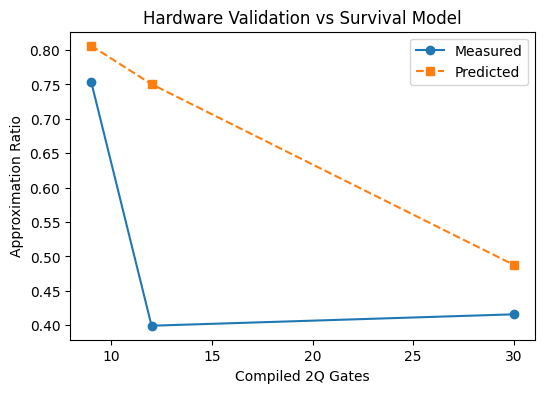

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(validation_df["compiled_2Q"],
         validation_df["hardware_ratio"],
         "o-", label="Measured")

plt.plot(validation_df["compiled_2Q"],
         validation_df["predicted_survival"],
         "s--", label="Predicted")

plt.xlabel("Compiled 2Q Gates")
plt.ylabel("Approximation Ratio")
plt.title("Hardware Validation vs Survival Model")
plt.legend()
plt.show()

In [14]:
validation_df.to_json("../results/problemB_hardware_validation.json", indent=2)

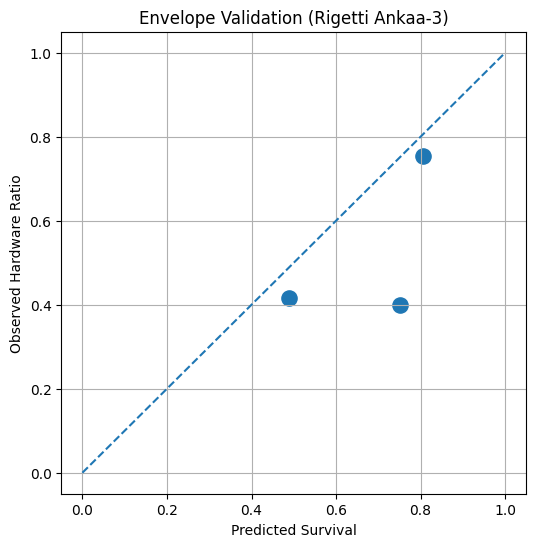

In [15]:
plt.figure(figsize=(6,6))

plt.scatter(
    validation_df["predicted_survival"],
    validation_df["hardware_ratio"],
    s=120
)

plt.plot([0,1], [0,1], '--')  # identity line

plt.xlabel("Predicted Survival")
plt.ylabel("Observed Hardware Ratio")
plt.title("Envelope Validation (Rigetti Ankaa-3)")

plt.grid(True)
plt.show()

In [19]:
# ─────────────────────────────────────────────
# Hardware Gamma Robustness Sweep
# ─────────────────────────────────────────────

SWEEP_POINTS = 7
DELTA = 0.3  # sweep range around optimal

idx = 11  # use best-behaving cluster
r = cluster_results[idx]
cluster_nodes = clusters[idx]
subG = GB.subgraph(cluster_nodes).copy()

gamma_opt = r["gamma"][0] if isinstance(r["gamma"], list) else r["gamma"]
beta_opt = r["beta"][0] if isinstance(r["beta"], list) else r["beta"]

gammas = np.linspace(gamma_opt - DELTA, gamma_opt + DELTA, SWEEP_POINTS)

sweep_results = []

for g in gammas:

    print(f"Running γ = {g:.3f}")

    prog, nodes = build_hardware_qaoa(subG, g, beta_opt)
    executable = qc.compile(prog)
    result = qc.run(executable, shots=1500)

    bitstrings = result.get_register_map()["ro"]

    best_cut = -1
    for row in bitstrings:
        bitstring = "".join(str(b) for b in row[::-1])
        spins = {nodes[i]: (1 if bitstring[i]=='0' else -1)
                 for i in range(len(nodes))}
        cut = sum(d["weight"] for u, v, d in subG.edges(data=True)
                  if spins[u] != spins[v])
        best_cut = max(best_cut, cut)

    sweep_results.append({"gamma": g, "cut": best_cut})

gamma_df = pd.DataFrame(sweep_results)
gamma_df

Running γ = 2.696
Running γ = 2.796
Running γ = 2.896
Running γ = 2.996
Running γ = 3.096
Running γ = 3.196
Running γ = 3.296


,gamma,cut
0,2.696446,227.698272
1,2.796446,371.106695
2,2.896446,168.003535
3,2.996446,220.724665
4,3.096446,320.265902
5,3.196446,125.257361
6,3.296446,231.364703


In [20]:
# ─────────────────────────────────────────────
# Shot Scaling Study
# ─────────────────────────────────────────────

shot_list = [500, 1000, 2000, 4000]

shot_results = []

for shots in shot_list:

    print(f"Running {shots} shots")

    prog, nodes = build_hardware_qaoa(subG, gamma_opt, beta_opt)
    executable = qc.compile(prog)
    result = qc.run(executable, shots=shots)

    bitstrings = result.get_register_map()["ro"]

    best_cut = -1
    for row in bitstrings:
        bitstring = "".join(str(b) for b in row[::-1])
        spins = {nodes[i]: (1 if bitstring[i]=='0' else -1)
                 for i in range(len(nodes))}
        cut = sum(d["weight"] for u, v, d in subG.edges(data=True)
                  if spins[u] != spins[v])
        best_cut = max(best_cut, cut)

    shot_results.append({"shots": shots, "cut": best_cut})

shot_df = pd.DataFrame(shot_results)
shot_df

Running 500 shots
Running 1000 shots
Running 2000 shots
Running 4000 shots


,shots,cut
0,500,275.639391
1,1000,193.026871
2,2000,196.281326
3,4000,215.070229


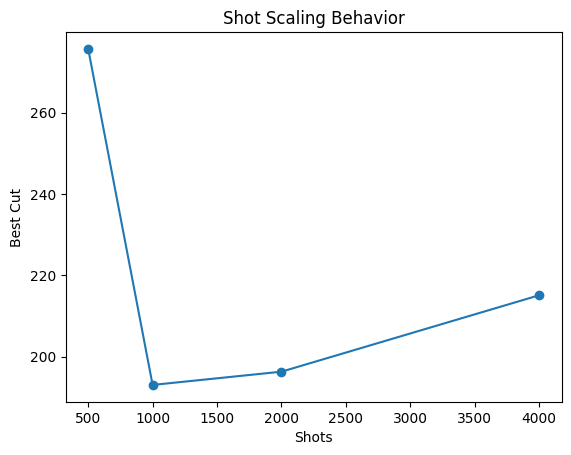

In [21]:
plt.plot(shot_df["shots"], shot_df["cut"], "o-")
plt.xlabel("Shots")
plt.ylabel("Best Cut")
plt.title("Shot Scaling Behavior")
plt.show()

In [22]:
empirical_survival = hardware_ratio

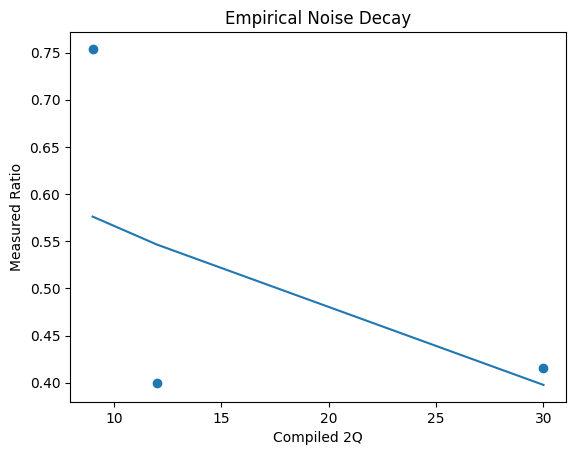

In [23]:
import numpy as np

x = validation_df["compiled_2Q"].values
y = validation_df["hardware_ratio"].values

coeff = np.polyfit(x, np.log(y), 1)
fit_line = np.exp(coeff[1] + coeff[0]*x)

plt.scatter(x, y)
plt.plot(x, fit_line)
plt.xlabel("Compiled 2Q")
plt.ylabel("Measured Ratio")
plt.title("Empirical Noise Decay")
plt.show()

In [24]:
# ─────────────────────────────────────────────
# Hardware Local Angle Refinement (2D Scan)
# ─────────────────────────────────────────────

idx = 11
r = cluster_results[idx]
cluster_nodes = clusters[idx]
subG = GB.subgraph(cluster_nodes).copy()

gamma_opt = r["gamma"][0] if isinstance(r["gamma"], list) else r["gamma"]
beta_opt  = r["beta"][0] if isinstance(r["beta"], list) else r["beta"]

delta_g = 0.2
delta_b = 0.2

gamma_vals = np.linspace(gamma_opt - delta_g, gamma_opt + delta_g, 5)
beta_vals  = np.linspace(beta_opt - delta_b, beta_opt + delta_b, 5)

grid_results = []

for g in gamma_vals:
    for b in beta_vals:

        print(f"γ={g:.3f}, β={b:.3f}")

        prog, nodes = build_hardware_qaoa(subG, g, b)
        executable = qc.compile(prog)
        result = qc.run(executable, shots=1200)

        bitstrings = result.get_register_map()["ro"]

        best_cut = -1
        for row in bitstrings:
            bitstring = "".join(str(b) for b in row[::-1])
            spins = {nodes[i]: (1 if bitstring[i]=='0' else -1)
                     for i in range(len(nodes))}
            cut = sum(d["weight"] for u, v, d in subG.edges(data=True)
                      if spins[u] != spins[v])
            best_cut = max(best_cut, cut)

        grid_results.append({
            "gamma": g,
            "beta": b,
            "cut": best_cut
        })

grid_df = pd.DataFrame(grid_results)
grid_df.sort_values("cut", ascending=False).head()

γ=2.796, β=0.247
γ=2.796, β=0.347
γ=2.796, β=0.447
γ=2.796, β=0.547
γ=2.796, β=0.647
γ=2.896, β=0.247
γ=2.896, β=0.347
γ=2.896, β=0.447
γ=2.896, β=0.547
γ=2.896, β=0.647
γ=2.996, β=0.247
γ=2.996, β=0.347
γ=2.996, β=0.447
γ=2.996, β=0.547
γ=2.996, β=0.647
γ=3.096, β=0.247
γ=3.096, β=0.347
γ=3.096, β=0.447
γ=3.096, β=0.547
γ=3.096, β=0.647
γ=3.196, β=0.247
γ=3.196, β=0.347
γ=3.196, β=0.447
γ=3.196, β=0.547
γ=3.196, β=0.647


,gamma,beta,cut
12,2.996446,0.446993,322.280465
11,2.996446,0.346993,322.058331
8,2.896446,0.546993,318.091136
6,2.896446,0.346993,309.555371
10,2.996446,0.246993,294.582671
